In [ ]:
!nvidia-smi
import tensorflow as tf
print("GPU Available:", tf.config.list_physical_devices('GPU'))

Mon Aug  3 14:41:42 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   43C    P8              9W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [ ]:
!pip install -q kaggle tensorflow scikit-learn seaborn matplotlib opencv-python-headless

In [ ]:
import os
os.makedirs('/root/.kaggle', exist_ok=True)
!cp "/content/kaggle (5).json" /root/.kaggle/kaggle.json
!chmod 600 /root/.kaggle/kaggle.json

In [ ]:
!kaggle datasets download -d paultimothymooney/chest-xray-pneumonia
!unzip -q chest-xray-pneumonia.zip -d /content/data

Dataset URL: https://www.kaggle.com/datasets/paultimothymooney/chest-xray-pneumonia
License(s): other
100% 2.29G/2.29G [00:20<00:00, 121MB/s]



In [ ]:
import os
base_dir = '/content/data/chest_xray'
for split in ['train', 'val', 'test']:
    for cls in ['NORMAL', 'PNEUMONIA']:
        path = os.path.join(base_dir, split, cls)
        print(split, cls, '->', len(os.listdir(path)), 'images')

train NORMAL -> 1341 images
train PNEUMONIA -> 3875 images
val NORMAL -> 8 images
val PNEUMONIA -> 8 images
test NORMAL -> 234 images
test PNEUMONIA -> 390 images


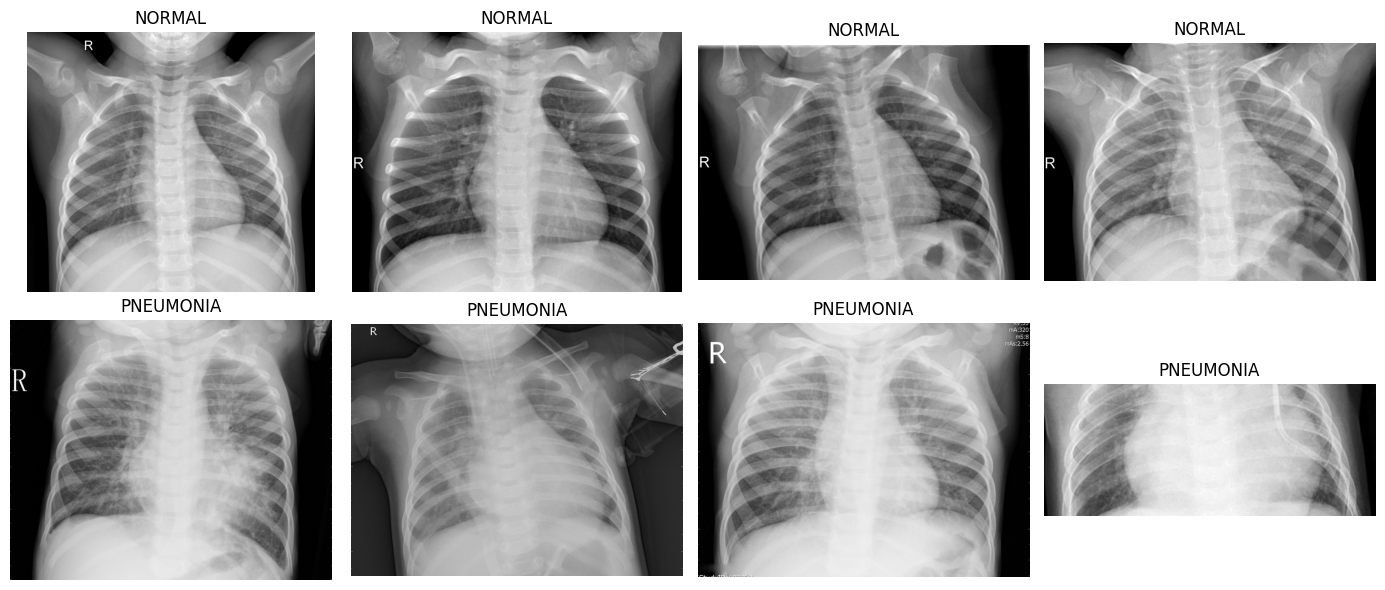

In [ ]:
import matplotlib.pyplot as plt
import cv2, random

fig, axes = plt.subplots(2, 4, figsize=(14,6))
for i, cls in enumerate(['NORMAL', 'PNEUMONIA']):
    folder = os.path.join(base_dir, 'train', cls)
    samples = random.sample(os.listdir(folder), 4)
    for j, img_name in enumerate(samples):
        img = cv2.imread(os.path.join(folder, img_name), cv2.IMREAD_GRAYSCALE)
        axes[i, j].imshow(img, cmap='gray')
        axes[i, j].set_title(cls)
        axes[i, j].axis('off')
plt.tight_layout()
plt.show()

In [ ]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

n_normal = len(os.listdir(os.path.join(base_dir,'train','NORMAL')))
n_pneu = len(os.listdir(os.path.join(base_dir,'train','PNEUMONIA')))

labels = [0]*n_normal + [1]*n_pneu
class_weights = compute_class_weight('balanced', classes=np.array([0,1]), y=labels)
class_weight_dict = {0: class_weights[0], 1: class_weights[1]}
print(class_weight_dict)

{0: np.float64(1.9448173005219984), 1: np.float64(0.6730322580645162)}


In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

IMG_SIZE = (224, 224)
BATCH_SIZE = 32

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=15,
    zoom_range=0.15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True
)
val_test_datagen = ImageDataGenerator(rescale=1./255)

train_gen = train_datagen.flow_from_directory(
    os.path.join(base_dir,'train'), target_size=IMG_SIZE,
    batch_size=BATCH_SIZE, class_mode='binary')

val_gen = val_test_datagen.flow_from_directory(
    os.path.join(base_dir,'val'), target_size=IMG_SIZE,
    batch_size=BATCH_SIZE, class_mode='binary')

test_gen = val_test_datagen.flow_from_directory(
    os.path.join(base_dir,'test'), target_size=IMG_SIZE,
    batch_size=BATCH_SIZE, class_mode='binary', shuffle=False)

Found 5216 images belonging to 2 classes.
Found 16 images belonging to 2 classes.
Found 624 images belonging to 2 classes.


In [ ]:
from tensorflow.keras import layers, models

baseline_model = models.Sequential([
    layers.Input(shape=(224,224,3)),
    layers.Conv2D(32, 3, activation='relu'), layers.MaxPooling2D(),
    layers.Conv2D(64, 3, activation='relu'), layers.MaxPooling2D(),
    layers.Conv2D(128, 3, activation='relu'), layers.MaxPooling2D(),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(1, activation='sigmoid')
])
baseline_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    11,075,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,169,089 (42.61 MB)

 Trainable params: 11,169,089 (42.61 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
baseline_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy', tf.keras.metrics.AUC(name='auc'),
             tf.keras.metrics.Recall(name='recall')]
)

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(monitor='val_auc', mode='max', patience=3, restore_best_weights=True)

history_baseline = baseline_model.fit(
    train_gen, validation_data=val_gen, epochs=10,
    class_weight=class_weight_dict, callbacks=[early_stop]
)

Epoch 1/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 122s 696ms/step - accuracy: 0.7885 - auc: 0.8711 - loss: 0.4600 - recall: 0.7902 - val_accuracy: 0.7500 - val_auc: 0.8828 - val_loss: 0.5612 - val_recall: 0.8750
Epoch 2/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 111s 680ms/step - accuracy: 0.8650 - auc: 0.9411 - loss: 0.3078 - recall: 0.8524 - val_accuracy: 0.7500 - val_auc: 0.8984 - val_loss: 0.4622 - val_recall: 0.6250
Epoch 3/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 116s 707ms/step - accuracy: 0.8836 - auc: 0.9524 - loss: 0.2797 - recall: 0.8728 - val_accuracy: 0.7500 - val_auc: 0.8906 - val_loss: 0.6964 - val_recall: 1.0000
Epoch 4/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 115s 709ms/step - accuracy: 0.8754 - auc: 0.9482 - loss: 0.2878 - recall: 0.8619 - val_accuracy: 0.6250 - val_auc: 0.8516 - val_loss: 0.9199 - val_recall: 1.0000
Epoch 5/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 116s 714ms/step - accuracy: 0.8978 - auc: 0.9616 - loss: 0.2508 - recall: 0.8865 - val_accuracy: 0.7500 - val_auc: 0.9062 - val_loss: 0.4740 - val_recal

In [ ]:
loss, acc, auc, recall = baseline_model.evaluate(test_gen)
print(f"Baseline -> Accuracy: {acc:.3f}, AUC: {auc:.3f}, Recall: {recall:.3f}")

20/20 ━━━━━━━━━━━━━━━━━━━━ 7s 267ms/step - accuracy: 0.8670 - auc: 0.9384 - loss: 0.3111 - recall: 0.8795
Baseline -> Accuracy: 0.867, AUC: 0.938, Recall: 0.879


In [ ]:
from tensorflow.keras.applications import MobileNetV2

base = MobileNetV2(input_shape=(224,224,3), include_top=False, weights='imagenet')
base.trainable = False

tl_model = models.Sequential([
    base,
    layers.GlobalAveragePooling2D(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(1, activation='sigmoid')
])

tl_model.compile(optimizer='adam', loss='binary_crossentropy',
                  metrics=['accuracy', tf.keras.metrics.AUC(name='auc'),
                           tf.keras.metrics.Recall(name='recall')])

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
history_tl = tl_model.fit(
    train_gen, validation_data=val_gen, epochs=8,
    class_weight=class_weight_dict, callbacks=[early_stop]
)

Epoch 1/8
163/163 ━━━━━━━━━━━━━━━━━━━━ 140s 735ms/step - accuracy: 0.9086 - auc: 0.9722 - loss: 0.2098 - recall: 0.9022 - val_accuracy: 0.8750 - val_auc: 0.9062 - val_loss: 0.2896 - val_recall: 0.7500
Epoch 2/8
163/163 ━━━━━━━━━━━━━━━━━━━━ 106s 653ms/step - accuracy: 0.9363 - auc: 0.9854 - loss: 0.1485 - recall: 0.9316 - val_accuracy: 0.8125 - val_auc: 0.9375 - val_loss: 0.2426 - val_recall: 0.7500
Epoch 3/8
163/163 ━━━━━━━━━━━━━━━━━━━━ 113s 691ms/step - accuracy: 0.9446 - auc: 0.9865 - loss: 0.1429 - recall: 0.9404 - val_accuracy: 0.8750 - val_auc: 0.9531 - val_loss: 0.3343 - val_recall: 0.7500
Epoch 4/8
163/163 ━━━━━━━━━━━━━━━━━━━━ 108s 663ms/step - accuracy: 0.9419 - auc: 0.9887 - loss: 0.1294 - recall: 0.9365 - val_accuracy: 0.8750 - val_auc: 0.9844 - val_loss: 0.2789 - val_recall: 0.7500
Epoch 5/8
163/163 ━━━━━━━━━━━━━━━━━━━━ 113s 694ms/step - accuracy: 0.9440 - auc: 0.9872 - loss: 0.1403 - recall: 0.9412 - val_accuracy: 0.9375 - val_auc: 0.9688 - val_loss: 0.2164 - val_recall: 1.

In [ ]:
base.trainable = True
for layer in base.layers[:-30]:
    layer.trainable = False

tl_model.compile(optimizer=tf.keras.optimizers.Adam(1e-5),
                  loss='binary_crossentropy',
                  metrics=['accuracy', tf.keras.metrics.AUC(name='auc'),
                           tf.keras.metrics.Recall(name='recall')])

history_finetune = tl_model.fit(
    train_gen, validation_data=val_gen, epochs=6,
    class_weight=class_weight_dict, callbacks=[early_stop]
)

Epoch 1/6
163/163 ━━━━━━━━━━━━━━━━━━━━ 140s 722ms/step - accuracy: 0.9153 - auc: 0.9741 - loss: 0.2070 - recall: 0.9092 - val_accuracy: 0.9375 - val_auc: 0.9688 - val_loss: 0.1902 - val_recall: 0.8750
Epoch 2/6
163/163 ━━━━━━━━━━━━━━━━━━━━ 109s 671ms/step - accuracy: 0.9348 - auc: 0.9841 - loss: 0.1566 - recall: 0.9301 - val_accuracy: 0.8125 - val_auc: 0.9531 - val_loss: 0.2708 - val_recall: 0.8750
Epoch 3/6
163/163 ━━━━━━━━━━━━━━━━━━━━ 112s 686ms/step - accuracy: 0.9461 - auc: 0.9887 - loss: 0.1315 - recall: 0.9430 - val_accuracy: 0.7500 - val_auc: 0.9375 - val_loss: 0.3553 - val_recall: 0.8750


In [ ]:
loss, acc, auc, recall = tl_model.evaluate(test_gen)
print(f"Fine-tuned MobileNetV2 -> Accuracy: {acc:.3f}, AUC: {auc:.3f}, Recall: {recall:.3f}")
final_model = tl_model

20/20 ━━━━━━━━━━━━━━━━━━━━ 9s 239ms/step - accuracy: 0.9119 - auc: 0.9698 - loss: 0.2125 - recall: 0.9385
Fine-tuned MobileNetV2 -> Accuracy: 0.912, AUC: 0.970, Recall: 0.938


20/20 ━━━━━━━━━━━━━━━━━━━━ 15s 490ms/step
              precision    recall  f1-score   support

      NORMAL       0.89      0.87      0.88       234
   PNEUMONIA       0.92      0.94      0.93       390

    accuracy                           0.91       624
   macro avg       0.91      0.90      0.91       624
weighted avg       0.91      0.91      0.91       624



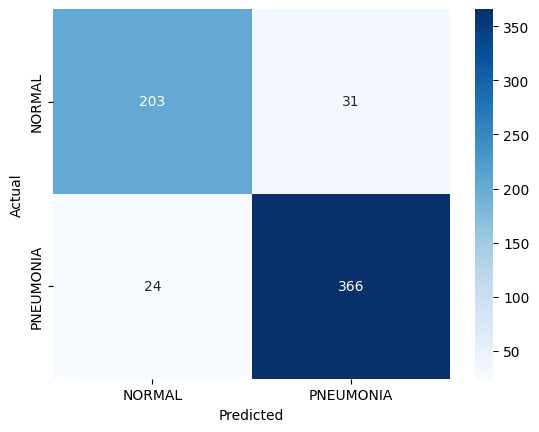

20/20 ━━━━━━━━━━━━━━━━━━━━ 6s 264ms/step


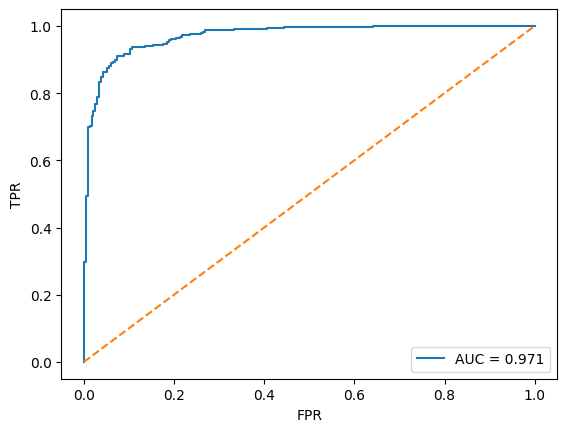

In [ ]:
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc
import seaborn as sns

preds = (final_model.predict(test_gen) > 0.5).astype(int).ravel()
y_true = test_gen.classes

print(classification_report(y_true, preds, target_names=['NORMAL','PNEUMONIA']))

cm = confusion_matrix(y_true, preds)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['NORMAL','PNEUMONIA'], yticklabels=['NORMAL','PNEUMONIA'])
plt.xlabel('Predicted'); plt.ylabel('Actual'); plt.show()

probs = final_model.predict(test_gen).ravel()
fpr, tpr, _ = roc_curve(y_true, probs)
plt.plot(fpr, tpr, label=f'AUC = {auc(fpr,tpr):.3f}')
plt.plot([0,1],[0,1],'--'); plt.xlabel('FPR'); plt.ylabel('TPR'); plt.legend(); plt.show()

In [ ]:
import numpy as np
import matplotlib.cm as cm_map

def grad_cam(model, img_array, last_conv_layer_name):
    grad_model = tf.keras.models.Model(
        [model.inputs], [model.get_layer(last_conv_layer_name).output, model.output]
    )
    with tf.GradientTape() as tape:
        conv_out, preds = grad_model(img_array)
        loss = preds[:, 0]
    grads = tape.gradient(loss, conv_out)
    pooled_grads = tf.reduce_mean(grads, axis=(0,1,2))
    conv_out = conv_out[0]
    heatmap = tf.reduce_sum(conv_out * pooled_grads, axis=-1)
    heatmap = tf.maximum(heatmap, 0) / (tf.math.reduce_max(heatmap) + 1e-8)
    return heatmap.numpy()


In [ ]:
final_model.save('/content/pneumonia_detector.h5')

def predict_xray(img_path, model=final_model):
    img = cv2.imread(img_path)
    img = cv2.resize(img, (224,224)) / 255.0
    img = np.expand_dims(img, axis=0)
    prob = model.predict(img)[0][0]
    label = "PNEUMONIA" if prob > 0.5 else "NORMAL"
    return label, float(prob)

from google.colab import files
files.download('/content/pneumonia_detector.h5')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>